# Outlier-Aware Dual-Channel Fast-PL Workflow

This notebook treats the low `PL_D` cluster near `5180` ADC as an artifact class and the upper cluster near `5222` ADC as the valid NV PL level.

## Objective
Build a full visualization workflow for:

1. identifying the bimodal NV distribution
2. separating the low-state artifact cluster from the high-state NV cluster
3. cleaning the NV trace by replacing the low-state samples with a high-state local baseline
4. applying the dual-channel correction to the cleaned NV trace
5. exporting the resulting corrected readout

## Final outputs
- `cleaned_nv_adc`: NV trace after removing the low-state artifact cluster
- `corrected_nv_adc_forced`: cleaned NV trace after forced dual-channel subtraction
- `final_nv_pl_recommended`: recommended final readout

For this dataset, if the dual-channel gate fails after outlier cleaning, the recommended final readout is the cleaned NV trace itself.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, coherence, filtfilt, welch

plt.style.use('default')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

In [ ]:
ROOT = Path('/Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer')
CSV_PATH = ROOT / 'Initial Test/fast_PL_dual_channel_laser.csv'
REFERENCE_COL = 'PL_C'
SIGNAL_COL = 'PL_D'
LOWPASS_CUTOFF_HZ = 20.0
ROLLING_BASELINE_WINDOW = 2001
EXPORT_PATH = ROOT / 'Initial Test/fast_PL_dual_channel_laser_outlier_aware_nv_readout.csv'

print(CSV_PATH)
print(EXPORT_PATH)

/Users/ckasemtantikul/Documents/PhD/NV Diamond/Initial Test/fast_PL_dual_channel_laser.csv
/Users/ckasemtantikul/Documents/PhD/NV Diamond/Initial Test/fast_PL_dual_channel_laser_outlier_aware_nv_readout.csv


In [3]:
@dataclass
class OutlierAwareWorkflow:
    sample_rate_hz: float
    low_cluster_center: float
    high_cluster_center: float
    threshold_adc: float
    outlier_fraction: float
    alpha_cleaned: float
    corr_lowband_cleaned: float
    mean_coherence_0_50_hz_cleaned: float
    mode_after_cleaning: str
    dataframe: pd.DataFrame


def infer_sample_rate_hz(time_s: np.ndarray) -> float:
    return float(1.0 / np.median(np.diff(time_s)))


def bandpower(signal: np.ndarray, sample_rate_hz: float, band: tuple[float, float]) -> float:
    freqs, psd = welch(signal, fs=sample_rate_hz, nperseg=min(4096, len(signal)))
    lo, hi = band
    mask = (freqs >= lo) & (freqs < hi)
    if not np.any(mask):
        return 0.0
    return float(np.trapezoid(psd[mask], freqs[mask]))


def mean_band_coherence(signal: np.ndarray, reference: np.ndarray, sample_rate_hz: float, band=(0.0, 50.0)) -> float:
    freqs, coh = coherence(signal, reference, fs=sample_rate_hz, nperseg=min(2048, len(signal)))
    lo, hi = band
    mask = (freqs >= lo) & (freqs < hi)
    if not np.any(mask):
        return 0.0
    return float(np.nanmean(coh[mask]))


def lowpass(signal: np.ndarray, sample_rate_hz: float, cutoff_hz: float, order: int = 3) -> np.ndarray:
    nyquist_hz = 0.5 * sample_rate_hz
    normalized_cutoff = min(cutoff_hz / nyquist_hz, 0.99)
    b, a = butter(order, normalized_cutoff, btype='low')
    return filtfilt(b, a, signal)


def fractional_fluctuation(signal: np.ndarray) -> tuple[np.ndarray, float]:
    mean_value = float(np.mean(signal))
    return (signal - mean_value) / mean_value, mean_value


def fit_two_cluster_threshold(signal: np.ndarray) -> tuple[float, float, float]:
    c1 = float(np.quantile(signal, 0.2))
    c2 = float(np.quantile(signal, 0.8))
    for _ in range(100):
        assign_low = np.abs(signal - c1) <= np.abs(signal - c2)
        new_c1 = float(signal[assign_low].mean())
        new_c2 = float(signal[~assign_low].mean())
        if abs(new_c1 - c1) + abs(new_c2 - c2) < 1e-12:
            break
        c1, c2 = new_c1, new_c2
    low_center, high_center = sorted([c1, c2])
    threshold_adc = 0.5 * (low_center + high_center)
    return low_center, high_center, threshold_adc


def extract_runs(mask: np.ndarray, time_s: np.ndarray) -> pd.DataFrame:
    runs = []
    start = None
    for i, is_bad in enumerate(mask):
        if is_bad and start is None:
            start = i
        if (not is_bad) and (start is not None):
            runs.append({
                'start_idx': start,
                'end_idx': i - 1,
                'length': i - start,
                'start_time_s': float(time_s[start]),
                'end_time_s': float(time_s[i - 1]),
            })
            start = None
    if start is not None:
        runs.append({
            'start_idx': start,
            'end_idx': len(mask) - 1,
            'length': len(mask) - start,
            'start_time_s': float(time_s[start]),
            'end_time_s': float(time_s[-1]),
        })
    return pd.DataFrame(runs)


def clean_low_cluster(signal: np.ndarray, outlier_mask: np.ndarray, high_center: float, window: int) -> tuple[np.ndarray, np.ndarray]:
    series = pd.Series(signal)
    high_only = series.where(~outlier_mask)
    local_high_baseline = high_only.rolling(window=window, center=True, min_periods=1).median()
    local_high_baseline = local_high_baseline.interpolate(limit_direction='both').fillna(high_center)
    cleaned = series.copy()
    cleaned[outlier_mask] = local_high_baseline[outlier_mask]
    return cleaned.to_numpy(float), local_high_baseline.to_numpy(float)


def build_workflow(csv_path: Path) -> OutlierAwareWorkflow:
    df = pd.read_csv(csv_path).copy()
    time_s = df['time_s'].to_numpy(float)
    reference_raw = df[REFERENCE_COL].to_numpy(float)
    signal_raw = df[SIGNAL_COL].to_numpy(float)
    sample_rate_hz = infer_sample_rate_hz(time_s)

    low_center, high_center, threshold_adc = fit_two_cluster_threshold(signal_raw)
    outlier_mask = signal_raw < threshold_adc
    outlier_runs = extract_runs(outlier_mask, time_s)

    cleaned_nv, local_high_baseline = clean_low_cluster(
        signal_raw,
        outlier_mask,
        high_center=high_center,
        window=ROLLING_BASELINE_WINDOW,
    )

    reference_fractional, reference_mean = fractional_fluctuation(reference_raw)
    cleaned_fractional, cleaned_mean = fractional_fluctuation(cleaned_nv)

    reference_fractional_low = lowpass(reference_fractional, sample_rate_hz, LOWPASS_CUTOFF_HZ)
    cleaned_fractional_low = lowpass(cleaned_fractional, sample_rate_hz, LOWPASS_CUTOFF_HZ)

    alpha_cleaned = float(np.dot(reference_fractional_low, cleaned_fractional_low) / np.dot(reference_fractional_low, reference_fractional_low))
    corr_lowband_cleaned = float(np.corrcoef(cleaned_fractional_low, reference_fractional_low)[0, 1])
    mean_coh_cleaned = mean_band_coherence(cleaned_fractional_low, reference_fractional_low, sample_rate_hz, band=(0.0, 50.0))

    gate_pass = (abs(corr_lowband_cleaned) >= 0.15) or (mean_coh_cleaned >= 0.20)
    mode_after_cleaning = 'dual_channel_after_cleaning' if gate_pass else 'bypass_after_cleaning'

    common_mode_nv_adc_forced = alpha_cleaned * cleaned_mean * reference_fractional_low
    corrected_nv_adc_forced = cleaned_nv - common_mode_nv_adc_forced
    final_nv_pl_recommended = corrected_nv_adc_forced if gate_pass else cleaned_nv

    df['reference_raw_adc'] = reference_raw
    df['signal_raw_adc'] = signal_raw
    df['outlier_mask'] = outlier_mask.astype(int)
    df['local_high_baseline_adc'] = local_high_baseline
    df['cleaned_nv_adc'] = cleaned_nv
    df['reference_fractional'] = reference_fractional
    df['cleaned_fractional'] = cleaned_fractional
    df['reference_fractional_low'] = reference_fractional_low
    df['cleaned_fractional_low'] = cleaned_fractional_low
    df['common_mode_nv_adc_forced'] = common_mode_nv_adc_forced
    df['corrected_nv_adc_forced'] = corrected_nv_adc_forced
    df['final_nv_pl_recommended'] = final_nv_pl_recommended
    df['removed_outlier_component_adc'] = signal_raw - cleaned_nv
    df['removed_dual_channel_component_adc'] = cleaned_nv - corrected_nv_adc_forced

    # store outlier run info in repeated columns only for convenience in export-free workflow summary
    df.attrs['outlier_runs'] = outlier_runs

    return OutlierAwareWorkflow(
        sample_rate_hz=sample_rate_hz,
        low_cluster_center=low_center,
        high_cluster_center=high_center,
        threshold_adc=threshold_adc,
        outlier_fraction=float(outlier_mask.mean()),
        alpha_cleaned=alpha_cleaned,
        corr_lowband_cleaned=corr_lowband_cleaned,
        mean_coherence_0_50_hz_cleaned=mean_coh_cleaned,
        mode_after_cleaning=mode_after_cleaning,
        dataframe=df,
    )

## Build the Outlier-Aware Workflow

This cell creates the outlier mask, the cleaned NV trace, and the dual-channel outputs.

In [4]:
result = build_workflow(CSV_PATH)
runs_df = result.dataframe.attrs['outlier_runs']

summary = pd.DataFrame([{
    'sample_rate_hz': result.sample_rate_hz,
    'low_cluster_center': result.low_cluster_center,
    'high_cluster_center': result.high_cluster_center,
    'threshold_adc': result.threshold_adc,
    'outlier_fraction': result.outlier_fraction,
    'alpha_cleaned': result.alpha_cleaned,
    'corr_lowband_cleaned': result.corr_lowband_cleaned,
    'mean_coherence_0_50_hz_cleaned': result.mean_coherence_0_50_hz_cleaned,
    'mode_after_cleaning': result.mode_after_cleaning,
    'raw_std_adc': float(result.dataframe['signal_raw_adc'].std(ddof=0)),
    'cleaned_std_adc': float(result.dataframe['cleaned_nv_adc'].std(ddof=0)),
    'corrected_forced_std_adc': float(result.dataframe['corrected_nv_adc_forced'].std(ddof=0)),
    'final_recommended_std_adc': float(result.dataframe['final_nv_pl_recommended'].std(ddof=0)),
}])
summary.round(4)

,sample_rate_hz,low_cluster_center,high_cluster_center,threshold_adc,outlier_fraction,alpha_cleaned,corr_lowband_cleaned,mean_coherence_0_50_hz_cleaned,mode_after_cleaning,raw_std_adc,cleaned_std_adc,corrected_forced_std_adc,final_recommended_std_adc
0,4684.1771,5184.0834,5223.8052,5203.9443,0.278,0.0201,0.2718,0.0223,dual_channel_after_cleaning,18.1074,7.9548,7.6844,7.6844


## Step 1: Show the Bimodal NV Distribution

This histogram is the evidence for treating the low `PL_D` population as a separate artifact cluster rather than as ordinary NV fluctuation.

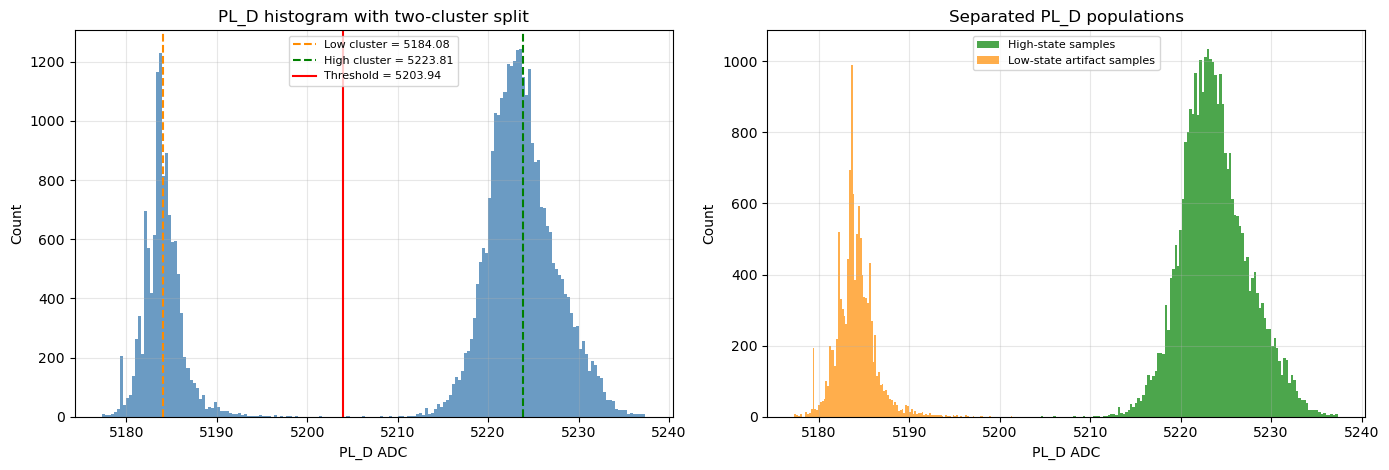

In [5]:
res = result.dataframe

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

axes[0].hist(res['signal_raw_adc'], bins=180, color='steelblue', alpha=0.8)
axes[0].axvline(result.low_cluster_center, color='darkorange', linestyle='--', linewidth=1.5, label=f'Low cluster = {result.low_cluster_center:.2f}')
axes[0].axvline(result.high_cluster_center, color='green', linestyle='--', linewidth=1.5, label=f'High cluster = {result.high_cluster_center:.2f}')
axes[0].axvline(result.threshold_adc, color='red', linestyle='-', linewidth=1.5, label=f'Threshold = {result.threshold_adc:.2f}')
axes[0].set_title('PL_D histogram with two-cluster split')
axes[0].set_xlabel('PL_D ADC')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].hist(res.loc[res['outlier_mask'] == 0, 'signal_raw_adc'], bins=120, color='green', alpha=0.7, label='High-state samples')
axes[1].hist(res.loc[res['outlier_mask'] == 1, 'signal_raw_adc'], bins=120, color='darkorange', alpha=0.7, label='Low-state artifact samples')
axes[1].set_title('Separated PL_D populations')
axes[1].set_xlabel('PL_D ADC')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Step 2: Show the Outlier Mask on the Time Trace

The low-state samples are not just isolated points. They appear as one long low run and many repeated bursts. This plot marks the samples treated as wrong.

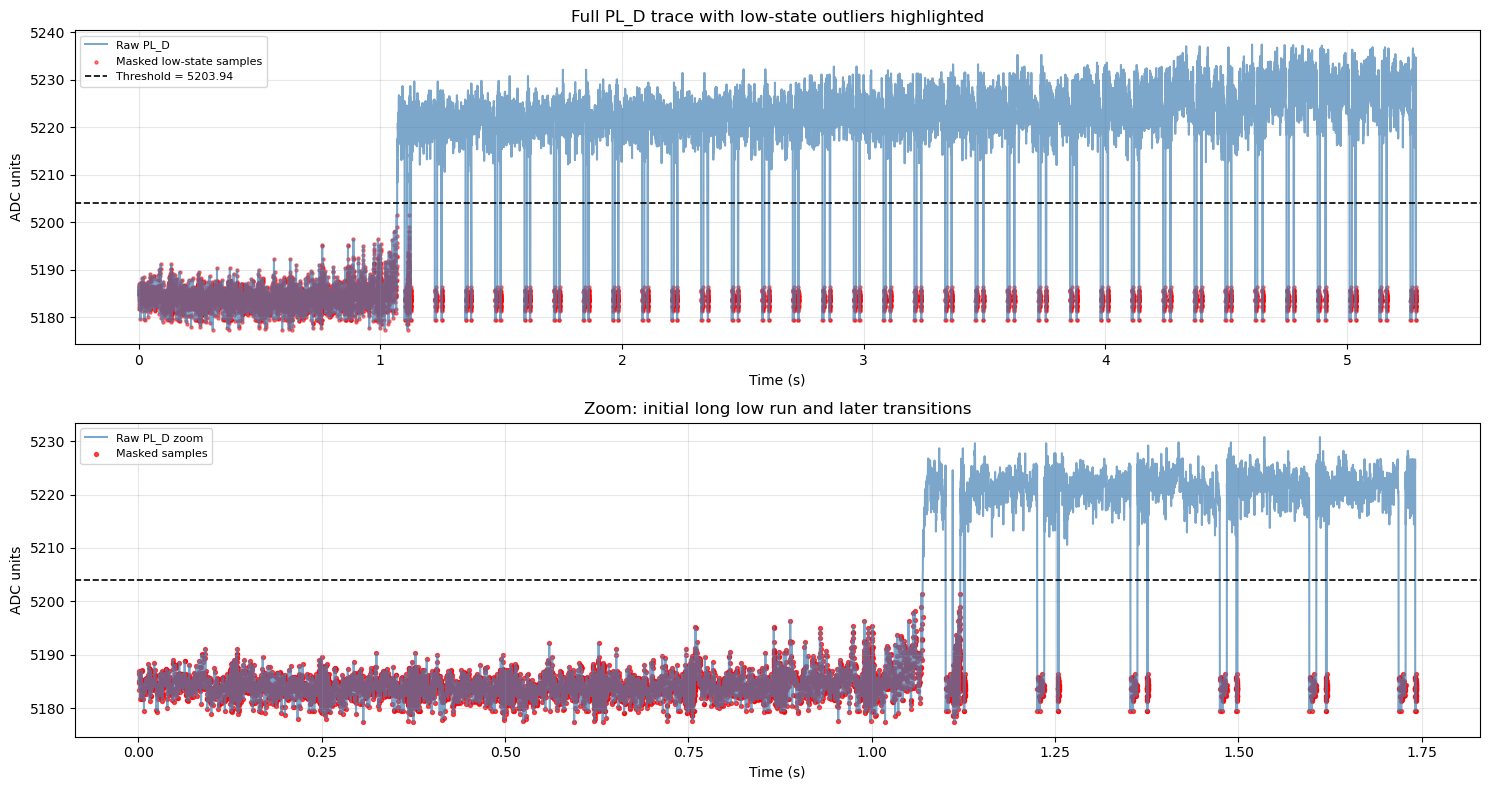

In [6]:
res = result.dataframe
sl = slice(0, min(14000, len(res)))
mask = res['outlier_mask'].to_numpy(bool)

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=False)

axes[0].plot(res['time_s'], res['signal_raw_adc'], color='steelblue', alpha=0.7, label='Raw PL_D')
axes[0].scatter(res.loc[mask, 'time_s'], res.loc[mask, 'signal_raw_adc'], s=5, color='red', alpha=0.5, label='Masked low-state samples')
axes[0].axhline(result.threshold_adc, color='black', linestyle='--', linewidth=1.2, label=f'Threshold = {result.threshold_adc:.2f}')
axes[0].set_title('Full PL_D trace with low-state outliers highlighted')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('ADC units')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].plot(res['time_s'].to_numpy(float)[sl], res['signal_raw_adc'].to_numpy(float)[sl], color='steelblue', alpha=0.7, label='Raw PL_D zoom')
zoom_mask = mask[sl]
axes[1].scatter(res['time_s'].to_numpy(float)[sl][zoom_mask], res['signal_raw_adc'].to_numpy(float)[sl][zoom_mask], s=8, color='red', alpha=0.7, label='Masked samples')
axes[1].axhline(result.threshold_adc, color='black', linestyle='--', linewidth=1.2)
axes[1].set_title('Zoom: initial long low run and later transitions')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('ADC units')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Step 3: Run Structure of the Low-State Artifact

This summarizes the timing structure of the low-state segments.

In [7]:
runs_df.head(12)

,start_idx,end_idx,length,start_time_s,end_time_s
0,0,8308,8309,0.000250,1.069199
1,8455,8499,45,1.100770,1.110219
2,8501,8808,308,1.110404,1.120645
3,8955,8999,45,1.125549,1.127017
4,9455,9499,45,1.225630,1.235138
5,9955,9999,45,1.253382,1.255127
6,10455,10499,45,1.352769,1.362180
7,10955,10999,45,1.375328,1.376590
8,11455,11499,45,1.474694,1.484153
9,11955,11999,45,1.497134,1.498379


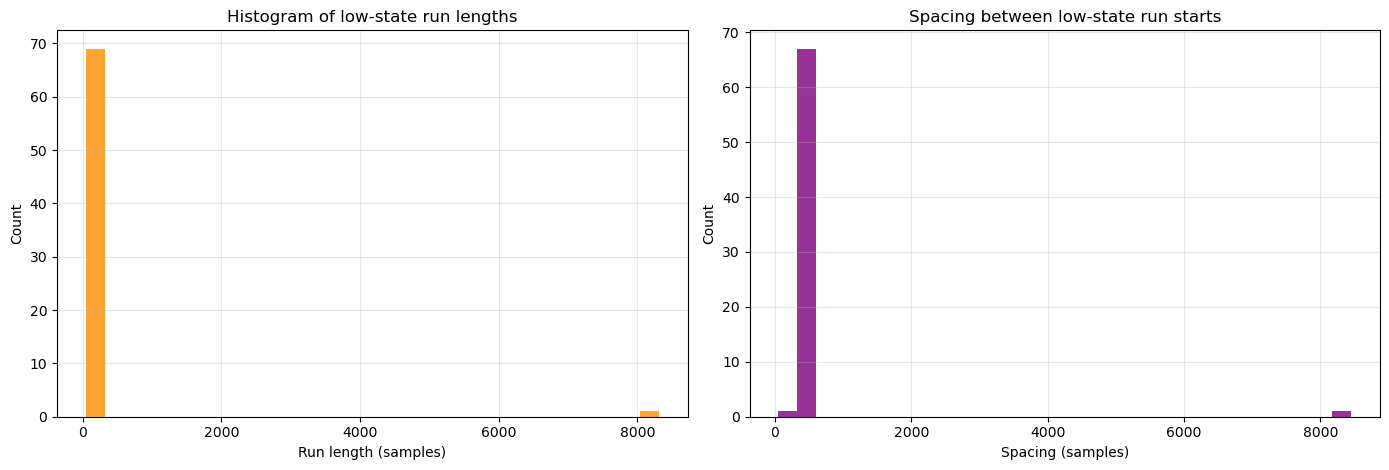

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

axes[0].hist(runs_df['length'], bins=min(30, len(runs_df)), color='darkorange', alpha=0.8)
axes[0].set_title('Histogram of low-state run lengths')
axes[0].set_xlabel('Run length (samples)')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

if len(runs_df) > 1:
    spacing_samples = np.diff(runs_df['start_idx'])
    axes[1].hist(spacing_samples, bins=min(30, len(spacing_samples)), color='purple', alpha=0.8)
    axes[1].set_title('Spacing between low-state run starts')
    axes[1].set_xlabel('Spacing (samples)')
    axes[1].set_ylabel('Count')
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].axis('off')

plt.tight_layout()
plt.show()

## Step 4: Build the Cleaned NV Trace

The low-state samples are replaced by a local rolling median computed only from the high-state samples. This creates a high-state-only estimate of the NV readout.

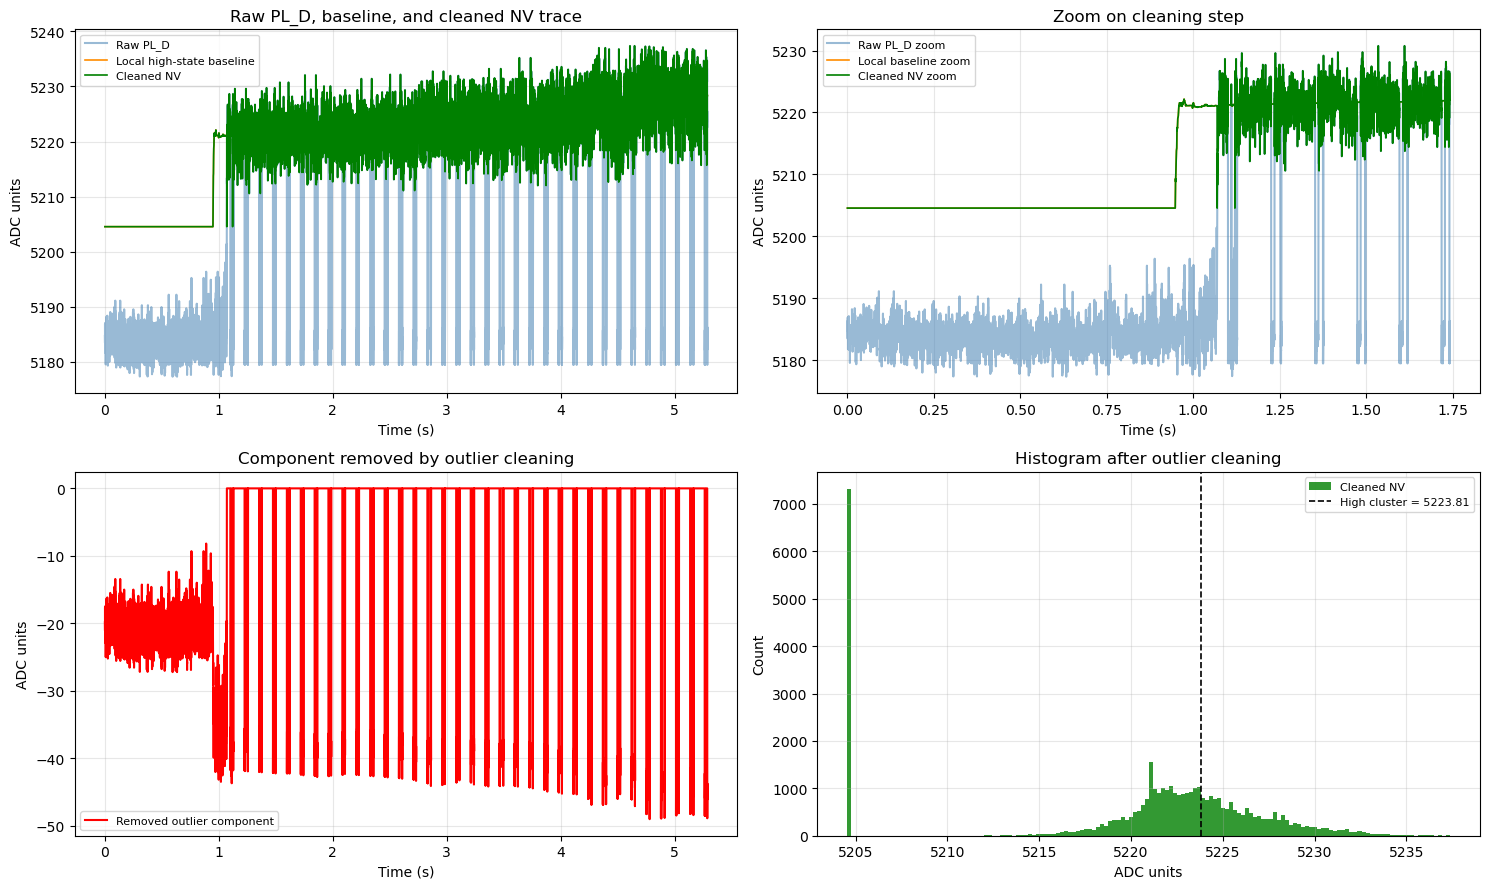

In [9]:
res = result.dataframe
sl = slice(0, min(14000, len(res)))

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

axes[0, 0].plot(res['time_s'], res['signal_raw_adc'], color='steelblue', alpha=0.55, label='Raw PL_D')
axes[0, 0].plot(res['time_s'], res['local_high_baseline_adc'], color='darkorange', linewidth=1.2, label='Local high-state baseline')
axes[0, 0].plot(res['time_s'], res['cleaned_nv_adc'], color='green', linewidth=1.2, label='Cleaned NV')
axes[0, 0].set_title('Raw PL_D, baseline, and cleaned NV trace')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('ADC units')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(res['time_s'].to_numpy(float)[sl], res['signal_raw_adc'].to_numpy(float)[sl], color='steelblue', alpha=0.55, label='Raw PL_D zoom')
axes[0, 1].plot(res['time_s'].to_numpy(float)[sl], res['local_high_baseline_adc'].to_numpy(float)[sl], color='darkorange', linewidth=1.2, label='Local baseline zoom')
axes[0, 1].plot(res['time_s'].to_numpy(float)[sl], res['cleaned_nv_adc'].to_numpy(float)[sl], color='green', linewidth=1.2, label='Cleaned NV zoom')
axes[0, 1].set_title('Zoom on cleaning step')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('ADC units')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(res['time_s'], res['removed_outlier_component_adc'], color='red', label='Removed outlier component')
axes[1, 0].set_title('Component removed by outlier cleaning')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('ADC units')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(fontsize=8)

axes[1, 1].hist(res['cleaned_nv_adc'], bins=150, color='green', alpha=0.8, label='Cleaned NV')
axes[1, 1].axvline(result.high_cluster_center, color='black', linestyle='--', linewidth=1.2, label=f'High cluster = {result.high_cluster_center:.2f}')
axes[1, 1].set_title('Histogram after outlier cleaning')
axes[1, 1].set_xlabel('ADC units')
axes[1, 1].set_ylabel('Count')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Step 5: Dual-Channel Correction on the Cleaned NV Trace

After the low-state artifacts are removed, the laser-reference channel is used to test for remaining shared low-band structure. The forced correction is shown even if the post-cleaning gate is weak.

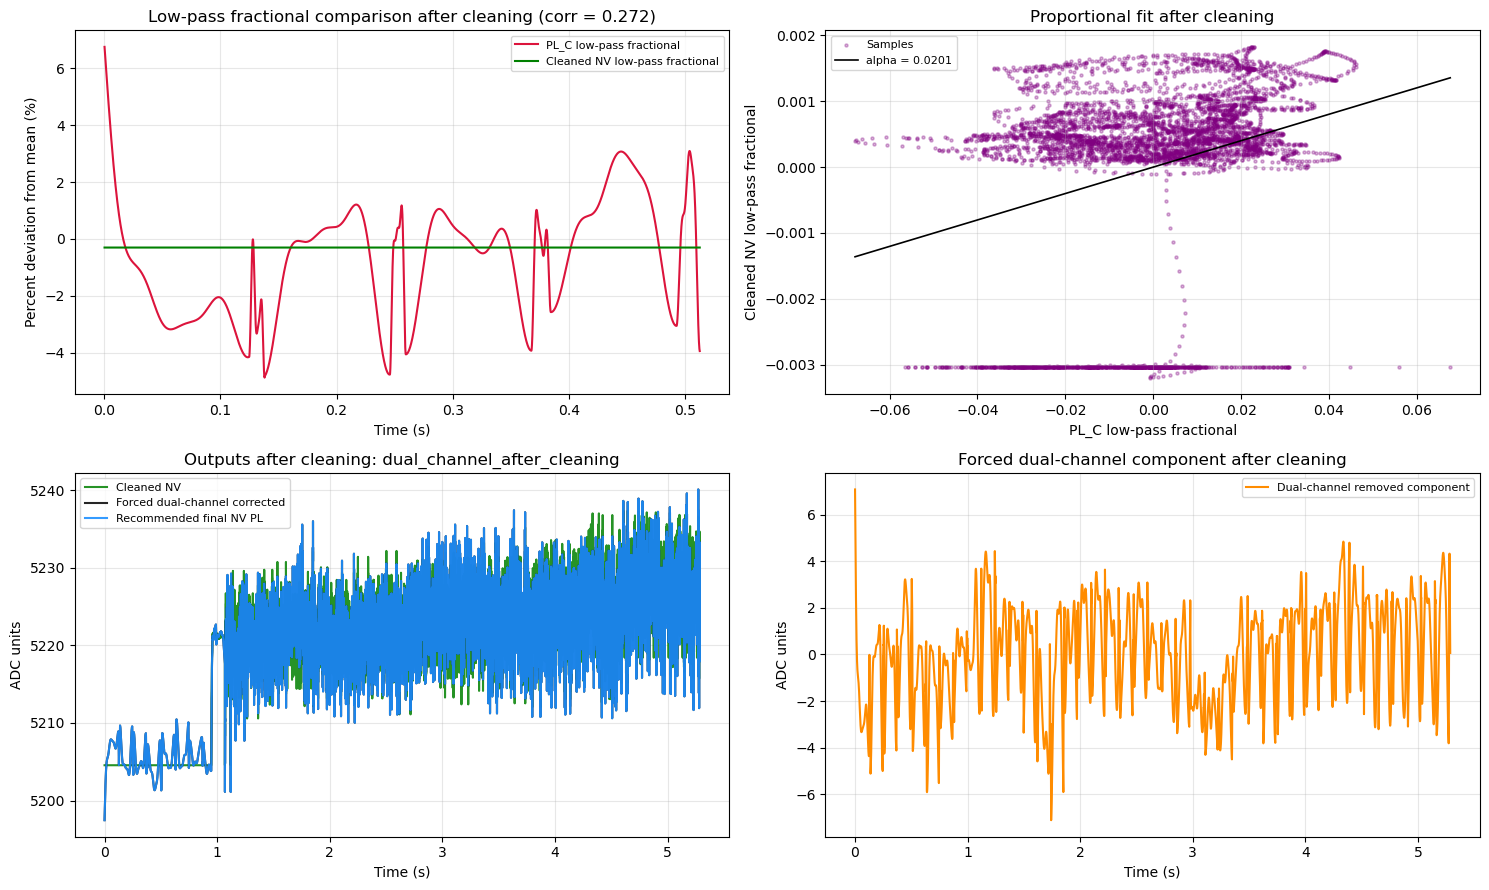

In [10]:
res = result.dataframe
sl = slice(0, min(4000, len(res)))

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

axes[0, 0].plot(res['time_s'].to_numpy(float)[sl], 100 * res['reference_fractional_low'].to_numpy(float)[sl], color='crimson', label='PL_C low-pass fractional')
axes[0, 0].plot(res['time_s'].to_numpy(float)[sl], 100 * res['cleaned_fractional_low'].to_numpy(float)[sl], color='green', label='Cleaned NV low-pass fractional')
axes[0, 0].set_title(f'Low-pass fractional comparison after cleaning (corr = {result.corr_lowband_cleaned:.3f})')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Percent deviation from mean (%)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=8)

x = res['reference_fractional_low'].to_numpy(float)
y = res['cleaned_fractional_low'].to_numpy(float)
line_x = np.linspace(x.min(), x.max(), 200)
line_y = result.alpha_cleaned * line_x
axes[0, 1].scatter(x[::8], y[::8], s=5, alpha=0.3, color='purple', label='Samples')
axes[0, 1].plot(line_x, line_y, color='black', linewidth=1.2, label=f'alpha = {result.alpha_cleaned:.4f}')
axes[0, 1].set_title('Proportional fit after cleaning')
axes[0, 1].set_xlabel('PL_C low-pass fractional')
axes[0, 1].set_ylabel('Cleaned NV low-pass fractional')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(res['time_s'], res['cleaned_nv_adc'], color='green', alpha=0.85, label='Cleaned NV')
axes[1, 0].plot(res['time_s'], res['corrected_nv_adc_forced'], color='black', alpha=0.85, label='Forced dual-channel corrected')
axes[1, 0].plot(res['time_s'], res['final_nv_pl_recommended'], color='dodgerblue', alpha=0.9, label='Recommended final NV PL')
axes[1, 0].set_title(f'Outputs after cleaning: {result.mode_after_cleaning}')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('ADC units')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(fontsize=8)

axes[1, 1].plot(res['time_s'], res['removed_dual_channel_component_adc'], color='darkorange', label='Dual-channel removed component')
axes[1, 1].set_title('Forced dual-channel component after cleaning')
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('ADC units')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Step 6: PSD Comparison

This compares the raw NV trace, the outlier-cleaned NV trace, and the forced dual-channel corrected NV trace.

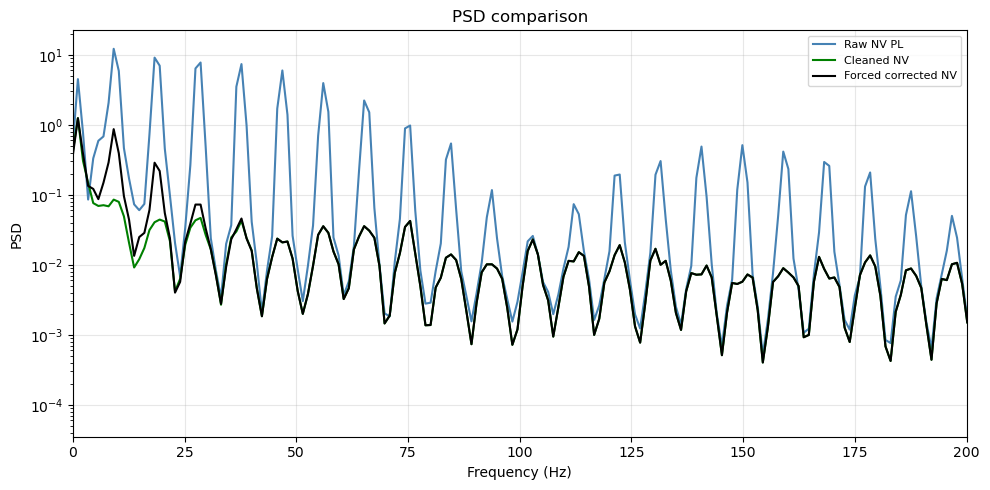

In [11]:
res = result.dataframe

fig, ax = plt.subplots(figsize=(10, 5))
for label, series, color in [
    ('Raw NV PL', res['signal_raw_adc'], 'steelblue'),
    ('Cleaned NV', res['cleaned_nv_adc'], 'green'),
    ('Forced corrected NV', res['corrected_nv_adc_forced'], 'black'),
]:
    freqs, psd = welch(series.to_numpy(float), fs=result.sample_rate_hz, nperseg=min(4096, len(res)))
    ax.semilogy(freqs, psd, label=label, color=color)
ax.set_xlim(0, 200)
ax.set_title('PSD comparison')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Step 7: Monitor the Intermediate and Final Columns

This table exposes the full workflow numerically.

In [12]:
result.dataframe[[
    'time_s',
    'reference_raw_adc',
    'signal_raw_adc',
    'outlier_mask',
    'local_high_baseline_adc',
    'cleaned_nv_adc',
    'reference_fractional_low',
    'cleaned_fractional_low',
    'common_mode_nv_adc_forced',
    'corrected_nv_adc_forced',
    'final_nv_pl_recommended',
]].head(12)

,time_s,reference_raw_adc,signal_raw_adc,outlier_mask,local_high_baseline_adc,cleaned_nv_adc,reference_fractional_low,cleaned_fractional_low,common_mode_nv_adc_forced,corrected_nv_adc_forced,final_nv_pl_recommended
0,0.000250,29.096010,5184.702007,1,5204.549935,5204.549935,0.067568,-0.00303,7.084404,5197.465531,5197.465531
1,0.000499,25.768429,5186.303090,1,5204.549935,5204.549935,0.066090,-0.00303,6.929482,5197.620453,5197.620453
2,0.000749,25.797299,5184.992203,1,5204.549935,5204.549935,0.064616,-0.00303,6.774921,5197.775014,5197.775014
3,0.000998,24.652003,5183.452247,1,5204.549935,5204.549935,0.063146,-0.00303,6.620786,5197.929149,5197.929149
4,0.001248,26.388861,5186.895033,1,5204.549935,5204.549935,0.061681,-0.00303,6.467144,5198.082791,5198.082791
5,0.001497,26.389731,5184.887633,1,5204.549935,5204.549935,0.060221,-0.00303,6.314060,5198.235875,5198.235875
6,0.001747,24.810925,5185.789685,1,5204.549935,5204.549935,0.058766,-0.00303,6.161599,5198.388336,5198.388336
7,0.001996,24.288975,5181.745983,1,5204.549935,5204.549935,0.057319,-0.00303,6.009827,5198.540109,5198.540109
8,0.002246,28.586877,5186.597009,1,5204.549935,5204.549935,0.055879,-0.00303,5.858807,5198.691128,5198.691128
9,0.002496,26.633524,5183.967193,1,5204.549935,5204.549935,0.054446,-0.00303,5.708604,5198.841332,5198.841332


## Step 8: Summary and Export

The exported file contains the raw trace, the outlier mask, the cleaned NV trace, the forced dual-channel correction, and the recommended final NV PL readout.

In [13]:
res = result.dataframe
summary_final = pd.DataFrame([{
    'sample_rate_hz': result.sample_rate_hz,
    'low_cluster_center': result.low_cluster_center,
    'high_cluster_center': result.high_cluster_center,
    'threshold_adc': result.threshold_adc,
    'outlier_fraction': result.outlier_fraction,
    'alpha_cleaned': result.alpha_cleaned,
    'corr_lowband_cleaned': result.corr_lowband_cleaned,
    'mean_coherence_0_50_hz_cleaned': result.mean_coherence_0_50_hz_cleaned,
    'mode_after_cleaning': result.mode_after_cleaning,
    'raw_std_adc': float(res['signal_raw_adc'].std(ddof=0)),
    'cleaned_std_adc': float(res['cleaned_nv_adc'].std(ddof=0)),
    'corrected_forced_std_adc': float(res['corrected_nv_adc_forced'].std(ddof=0)),
    'final_recommended_std_adc': float(res['final_nv_pl_recommended'].std(ddof=0)),
    'raw_bp_0_10': bandpower(res['signal_raw_adc'].to_numpy(float), result.sample_rate_hz, (0.0, 10.0)),
    'cleaned_bp_0_10': bandpower(res['cleaned_nv_adc'].to_numpy(float), result.sample_rate_hz, (0.0, 10.0)),
    'final_recommended_bp_0_10': bandpower(res['final_nv_pl_recommended'].to_numpy(float), result.sample_rate_hz, (0.0, 10.0)),
    'raw_bp_10_50': bandpower(res['signal_raw_adc'].to_numpy(float), result.sample_rate_hz, (10.0, 50.0)),
    'cleaned_bp_10_50': bandpower(res['cleaned_nv_adc'].to_numpy(float), result.sample_rate_hz, (10.0, 50.0)),
    'final_recommended_bp_10_50': bandpower(res['final_nv_pl_recommended'].to_numpy(float), result.sample_rate_hz, (10.0, 50.0)),
}])

res.to_csv(EXPORT_PATH, index=False)
print(EXPORT_PATH)
summary_final.round(4).T.rename(columns={0: 'value'})

/Users/ckasemtantikul/Documents/PhD/NV Diamond/Initial Test/fast_PL_dual_channel_laser_outlier_aware_nv_readout.csv


,value
sample_rate_hz,4684.1771
low_cluster_center,5184.0834
high_cluster_center,5223.8052
threshold_adc,5203.9443
outlier_fraction,0.278
alpha_cleaned,0.0201
corr_lowband_cleaned,0.2718
mean_coherence_0_50_hz_cleaned,0.0223
mode_after_cleaning,dual_channel_after_cleaning
raw_std_adc,18.1074
